# Main result: QW QNN vs the LAT kernel vs classical baselines (thesis Section 5.1.2)

Regenerates **Table 5.1** (`tab_lat_main.tex`) and **Figure 5.1** (`fig_lat_accuracy.pdf`) of the draft from scratch.

**Task** (Section 5.1.1). $p$ is the largest $n$-bit prime, $g$ its smallest generator, $x\in\mathbb Z_p^*$, $a=\log_g x$;
label $y=+1$ iff $a\in[s,\,s+\tfrac{p-3}{2}]$. Five draws per $n\in\{8,10,12,16\}$ (draw $i$ seeded with $1000n+i$),
150 training and 100 test inputs per draw, all distinct.

**Models.** Every model receives $x$.
- *Walk QNN*: discrete-log step $|x\rangle\mapsto|a\rangle$ (a lookup table in simulation) → top $h$ bits of $a$ select a vertex of
  $C_{2^h}$ → continuous-time walk $e^{-itA}$ → measured position, read out by a trainable diagonal observable fitted by ridge regression.
- *LAT kernel*: the same discrete-log step, then Liu–Arunachalam–Temme's kernel in an SVM.
- *Classical*: MLP, RBF-SVM, random forest on the $\pm1$ bits of $x$.

Hyperparameters by 5-fold stratified CV (seed 42) on the training set only; each test set scored once.
Runs on a laptop CPU in roughly 5–10 minutes (the MLP grid dominates). Needs numpy, scipy, scikit-learn, pandas, matplotlib.

In [1]:
import os, sys, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # the shared package code/qwt
from qwt.lat import make_lat, bits, PRIMES
from qwt.selection import ct_walk_qnn, lat_kernel, CLASSICAL
from qwt.stats import mcnemar

SIZES, DRAWS = [8, 10, 12, 16], [0, 1, 2, 3, 4]
OUT = "results"; os.makedirs(OUT, exist_ok=True)
N_JOBS = -1                                         # parallel grid search for the classical models (results do not depend on it)

In [ ]:
# Run every model on every draw 
rows = []
for n in SIZES:
    for draw in DRAWS:
        d = make_lat(n, draw)
        fits = {"Walk QNN": lambda: ct_walk_qnn(d["a_tr"], d["y_tr"], d["a_te"], d["p"], n),
                "LAT kernel": lambda: lat_kernel(d["a_tr"], d["y_tr"], d["a_te"], d["p"], n)}
        for name, fn in CLASSICAL.items():
            fits[name] = (lambda fn=fn: fn(bits(d["x_tr"], n), d["y_tr"], bits(d["x_te"], n), n_jobs=N_JOBS))
        for name, fit in fits.items():
            t0 = time.time()
            cv_acc, hp, pred = fit()
            correct = (pred == d["y_te"]).astype(int)
            rows.append(dict(n=n, draw=draw, model=name, cv_acc=float(cv_acc), test_acc=float(correct.mean()),
                             hp=hp, correct=correct.tolist()))
            print(f"n={n:2d} draw={draw} {name:14s} test={correct.mean():.3f}  {hp}  ({time.time() - t0:.1f}s)", flush=True)
R = pd.DataFrame(rows)
R.to_json(os.path.join(OUT, "main_result.json"), orient="records", indent=1)

n= 8 draw=0 Walk QNN       test=0.970  {'h': 6, 't': 1.5, 'ridge': 0.01}  (24.9s)


n= 8 draw=0 LAT kernel     test=0.970  {'C': 1, 'k': 5}  (0.6s)


n= 8 draw=0 MLP            test=0.560  {'alpha': 0.001, 'hidden_layer_sizes': '(10, 10, 10, 10)', 'learning_rate_init': 0.001}  (12.1s)


n= 8 draw=0 SVM (RBF)      test=0.440  {'C': 0.1, 'gamma': 0.001}  (0.2s)


n= 8 draw=0 Random forest  test=0.460  {'max_depth': None, 'n_estimators': 100}  (2.0s)


...

n=16 draw=4 Walk QNN       test=0.990  {'h': 3, 't': 0.1, 'ridge': 0.001}  (24.2s)


n=16 draw=4 LAT kernel     test=0.990  {'C': 1, 'k': 12}  (1.3s)


n=16 draw=4 MLP            test=0.410  {'alpha': 0.001, 'hidden_layer_sizes': '(50, 10, 5)', 'learning_rate_init': 0.1}  (3.0s)


n=16 draw=4 SVM (RBF)      test=0.540  {'C': 0.1, 'gamma': 0.001}  (0.1s)


n=16 draw=4 Random forest  test=0.400  {'max_depth': 8, 'n_estimators': 100}  (1.7s)


In [ ]:
# Table 5.1: test accuracy (%), mean ± s.d. over the five draws 
ORDER = ["Walk QNN", "LAT kernel", "MLP", "SVM (RBF)", "Random forest"]
S = R.groupby(["model", "n"]).test_acc.agg(["mean", "std"]).reset_index()
table = S.pivot(index="model", columns="n", values="mean").loc[ORDER]
sd = S.pivot(index="model", columns="n", values="std").loc[ORDER]
display((100 * table).round(1).astype(str) + " ± " + (100 * sd).round(1).astype(str))

TEX = {"Walk QNN": r"Walk QNN: DLP $\to$ CTQW $\to$ read-out", "LAT kernel": r"LAT: DLP $\to$ kernel SVM"}
lines = [r"\begin{table}[htbp]", r"\centering", r"\small", r"\setlength{\tabcolsep}{4pt}",
         r"\caption[Discrete-logarithm task: main comparison]{Discrete-logarithm task: test accuracy (\%) over five draws; "
         r"every model receives $x$, and $n$ is the bit length of $p$. DLP: Shor's discrete-logarithm step; CTQW: continuous-time quantum walk.}",
         r"\label{tab:latmain}", r"\begin{tabular}{l" + "r" * len(SIZES) + "}", r"\hline",
         "Model & " + " & ".join(f"$n={n}$" for n in SIZES) + r" \\", r"\hline"]
for m in ORDER:
    lines.append(TEX.get(m, m) + " & " + " & ".join(f"${100 * table.loc[m, n]:.1f} \pm {100 * sd.loc[m, n]:.1f}$" for n in SIZES) + r" \\")
lines += [r"\hline", r"\end{tabular}", r"\end{table}", ""]
_ = open(os.path.join(OUT, "tab_lat_main.tex"), "w").write("\n".join(lines))

n,8,10,12,16
model,,,,
Walk QNN,99.4 ± 1.3,99.8 ± 0.4,100.0 ± 0.0,98.6 ± 1.7
LAT kernel,98.4 ± 1.1,99.6 ± 0.5,98.8 ± 1.8,98.2 ± 2.4
MLP,49.6 ± 4.6,49.8 ± 2.6,49.4 ± 3.2,48.8 ± 5.7
SVM (RBF),48.8 ± 4.2,48.4 ± 3.8,47.4 ± 5.3,54.2 ± 6.4
Random forest,50.0 ± 2.3,48.6 ± 6.2,43.6 ± 3.5,50.2 ± 8.2


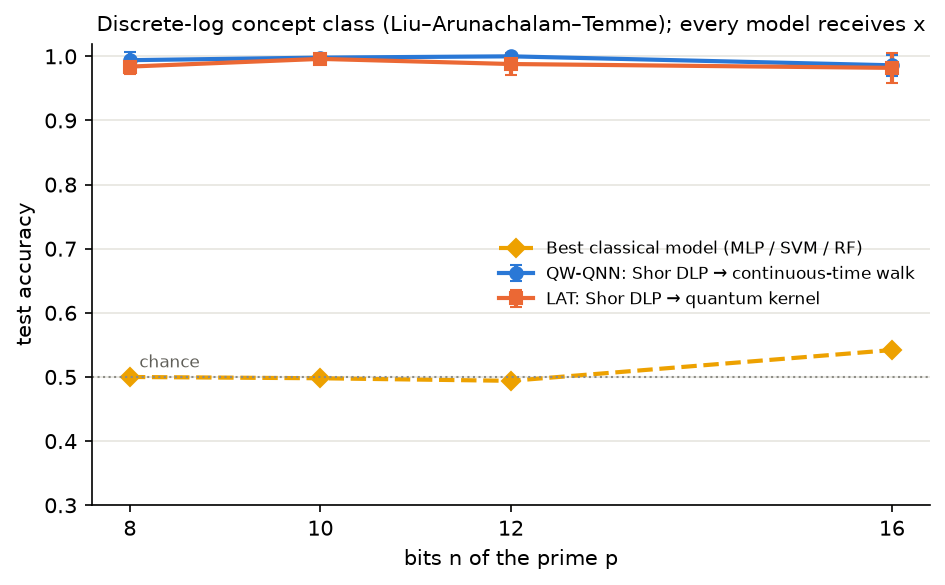

In [ ]:
# Figure 5.1: accuracy against problem size
fig, ax = plt.subplots(figsize=(6.4, 4.0), dpi=150)
for name, label, col, mk in [("Walk QNN", "QW-QNN: Shor DLP → continuous-time walk", "#2a78d6", "o"),
                             ("LAT kernel", "LAT: Shor DLP → quantum kernel", "#eb6834", "s")]:
    ax.errorbar(SIZES, table.loc[name], yerr=sd.loc[name], color=col, marker=mk, ms=6, lw=2, capsize=3, label=label)
best_classical = table.loc[["MLP", "SVM (RBF)", "Random forest"]].max()      # best classical model at each n, after the fact
ax.plot(SIZES, best_classical, color="#eda100", marker="D", ms=6, lw=2, ls="--", label="Best classical model (MLP / SVM / RF)")
ax.axhline(0.5, color="#8c8c86", lw=1, ls=":"); ax.text(SIZES[0] + 0.1, 0.515, "chance", fontsize=8, color="#5f5e58")
ax.set_xticks(SIZES); ax.set_xlabel("bits n of the prime p"); ax.set_ylabel("test accuracy")
ax.set_ylim(0.3, 1.02); ax.grid(axis="y", color="#e6e5df", lw=0.8); ax.set_axisbelow(True)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="center right")
ax.set_title("Discrete-log concept class (Liu–Arunachalam–Temme); every model receives x", fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "fig_lat_accuracy.pdf")); fig.savefig(os.path.join(OUT, "fig_lat_accuracy.png"))
plt.show()

In [ ]:
# paired exact McNemar tests quoted in Section 5.1.2 (test points pooled over the five draws) 
def correct(model, ns):
    return np.concatenate([R[(R.model == model) & (R.n == n)].sort_values("draw").correct.sum() for n in ns])

tests = []
for n in SIZES:
    best = table.loc[["MLP", "SVM (RBF)", "Random forest"], n].idxmax()
    for other in [best, "LAT kernel"]:
        a, b, p = mcnemar(correct("Walk QNN", [n]), correct(other, [n]))
        tests.append(dict(n=n, comparator=other, walk_only=a, other_only=b, p=p))
a, b, p = mcnemar(correct("Walk QNN", SIZES), correct("LAT kernel", SIZES))
tests.append(dict(n="pooled", comparator="LAT kernel", walk_only=a, other_only=b, p=p))
pd.DataFrame(tests)

,n,comparator,walk_only,other_only,p
0,8,Random forest,249,2,1.748071e-71
1,8,LAT kernel,5,0,6.250000e-02
2,10,MLP,251,1,6.991842e-74
3,10,LAT kernel,2,1,1.000000e+00
4,12,MLP,253,0,1.381787e-76
5,12,LAT kernel,6,0,3.125000e-02
6,16,SVM (RBF),225,3,9.159806e-63
7,16,LAT kernel,3,1,6.250000e-01
8,pooled,LAT kernel,16,2,1.312256e-03


In [ ]:
# comparison with the numbers printed in draft (Table 5.1)
THESIS = {"Walk QNN": [99.4, 99.8, 100.0, 98.6], "LAT kernel": [98.4, 99.6, 98.8, 98.2],
          "MLP": [49.6, 49.8, 49.4, 48.8], "SVM (RBF)": [48.8, 48.4, 47.4, 54.2], "Random forest": [50.0, 48.6, 43.6, 50.2]}
diff = (100 * table).round(1) - pd.DataFrame(THESIS, index=SIZES).T.loc[ORDER]
print("regenerated minus thesis (percentage points):"); display(diff)
print("all equal" if (diff.abs() < 0.05).all().all() else "MISMATCH")

regenerated minus thesis (percentage points):


n,8,10,12,16
model,,,,
Walk QNN,0.0,0.0,0.0,0.0
LAT kernel,0.0,0.0,0.0,0.0
MLP,0.0,0.0,0.0,0.0
SVM (RBF),0.0,0.0,0.0,0.0
Random forest,0.0,0.0,0.0,0.0


all equal
